In [1]:
# Import Required Libraries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Load Dataset
df = pd.read_csv("cleaned_animal_disease_prediction.csv")
df

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,...,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction
0,Dog,Labrador,4,Male,25.0,Fever,Lethargy,Appetite Loss,Vomiting,3 days,...,No,No,No,No,No,No,No,39.5°C,120,Parvovirus
1,Cat,Siamese,2,Female,4.5,Coughing,Sneezing,Eye Discharge,Nasal Discharge,1 week,...,No,Yes,No,No,No,Yes,Yes,38.9°C,150,Upper Respiratory Infection
2,Cow,Holstein,3,Female,600.0,Fever,Nasal Discharge,Labored Breathing,Coughing,5 days,...,No,Yes,Yes,No,No,Yes,No,40.1°C,90,Foot and Mouth Disease
3,Dog,Beagle,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite Loss,2 days,...,Yes,No,No,No,No,No,No,39.2°C,130,Gastroenteritis
4,Cat,Persian,5,Male,3.8,Lethargy,Appetite Loss,Skin Lesions,No,2 weeks,...,No,No,No,No,Yes,No,No,38.7°C,160,Fungal Infection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,Horse,Thoroughbred,6,Female,500.0,Coughing,Labored Breathing,Nasal Discharge,Fever,10 days,...,No,Yes,Yes,No,No,Yes,No,39.8°C,85,Equine Influenza
427,Dog,German Shepherd,3,Female,30.0,Lameness,Fever,Skin Lesions,Lethargy,7 days,...,No,No,No,Yes,Yes,No,No,39.3°C,110,Lyme Disease
428,Cat,Maine Coon,2,Male,6.0,Vomiting,Appetite Loss,Lethargy,Diarrhea,4 days,...,Yes,No,No,No,No,No,No,39.1°C,140,Intestinal Parasites
429,Dog,Bulldog,5,Male,23.0,Labored Breathing,Coughing,Nasal Discharge,Appetite Loss,6 days,...,No,Yes,Yes,No,No,Yes,No,40.0°C,115,Canine Distemper


In [3]:
# === EDA: Overview ===
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)


Dataset Shape: (431, 22)

Missing Values:
 Animal_Type           0
Breed                 0
Age                   0
Gender                0
Weight                0
Symptom_1             0
Symptom_2             0
Symptom_3             0
Symptom_4             0
Duration              0
Appetite_Loss         0
Vomiting              0
Diarrhea              0
Coughing              0
Labored_Breathing     0
Lameness              0
Skin_Lesions          0
Nasal_Discharge       0
Eye_Discharge         0
Body_Temperature      0
Heart_Rate            0
Disease_Prediction    0
dtype: int64

Data Types:
 Animal_Type            object
Breed                  object
Age                     int64
Gender                 object
Weight                float64
Symptom_1              object
Symptom_2              object
Symptom_3              object
Symptom_4              object
Duration               object
Appetite_Loss          object
Vomiting               object
Diarrhea               object
Coughing    

In [4]:
# === Preprocessing ===
# Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Identify target column (assuming only one contains 'Disease_Prediction')
target_col = [col for col in df_encoded.columns if 'Disease_Prediction' in col][0]
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Standard Scaling for numerical values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# === Feature Selection ===
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

C:\Users\Lohith\anaconda3\envs\py39\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


In [6]:
# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

In [7]:
# === Define Models and Hyperparameter Grids ===
models = {
    "Random Forest": (RandomForestClassifier(), {
        "n_estimators": [100, 200],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5]
    }),
    "Decision Tree": (DecisionTreeClassifier(), {
        "criterion": ["gini", "entropy"],
        "max_depth": [10, 20, None]
    }),
    "KNN": (KNeighborsClassifier(), {
        "n_neighbors": [3, 5, 7],
        "weights": ['uniform', 'distance']
    })
}

In [8]:
# === Train, Tune & Evaluate Models ===
model_performance = {}

for name, (model, params) in models.items():
    print(f"\nTraining and Tuning: {name}")
    grid = GridSearchCV(model, param_grid=params, cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    print(f"Best Params: {grid.best_params_}")
    print(f"Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, preds))

    model_performance[name] = {
        "Best Params": grid.best_params_,
        "Accuracy": round(acc * 100, 2),
        "Classification Report": classification_report(y_test, preds, output_dict=True)
    }


Training and Tuning: Random Forest
Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy: 98.85%
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        86
           1       0.00      0.00      0.00         1

    accuracy                           0.99        87
   macro avg       0.49      0.50      0.50        87
weighted avg       0.98      0.99      0.98        87


Training and Tuning: Decision Tree
Best Params: {'criterion': 'gini', 'max_depth': 10}
Accuracy: 98.85%
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        86
           1       0.00      0.00      0.00         1

    accuracy                           0.99        87
   macro avg       0.49      0.50      0.50        87
weighted avg       0.98      0.99      0.98        87


Training and Tuning: KNN
Best Params: {'n_neighbors': 3, 'weights': 'uniform'}
Accuracy: 98.85%
              p

C:\Users\Lohith\anaconda3\envs\py39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lohith\anaconda3\envs\py39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lohith\anaconda3\envs\py39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\User

In [9]:
# === Naive Bayes (No Hyperparameters) ===
print("\nEvaluating Naive Bayes:")
nb = GaussianNB()
nb.fit(X_train, y_train)
preds_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, preds_nb)
print(f"Accuracy: {acc_nb * 100:.2f}%")
print(classification_report(y_test, preds_nb))

model_performance["Naive Bayes"] = {
    "Best Params": "Default",
    "Accuracy": round(acc_nb * 100, 2),
    "Classification Report": classification_report(y_test, preds_nb, output_dict=True)
}


Evaluating Naive Bayes:
Accuracy: 98.85%
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        86
           1       0.00      0.00      0.00         1

    accuracy                           0.99        87
   macro avg       0.49      0.50      0.50        87
weighted avg       0.98      0.99      0.98        87



C:\Users\Lohith\anaconda3\envs\py39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lohith\anaconda3\envs\py39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lohith\anaconda3\envs\py39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\User

In [10]:

# === Summary ===
print("\n=== Model Accuracy Summary ===")
for model, data in model_performance.items():
    print(f"{model}: {data['Accuracy']}%")


=== Model Accuracy Summary ===
Random Forest: 98.85%
Decision Tree: 98.85%
KNN: 98.85%
Naive Bayes: 98.85%


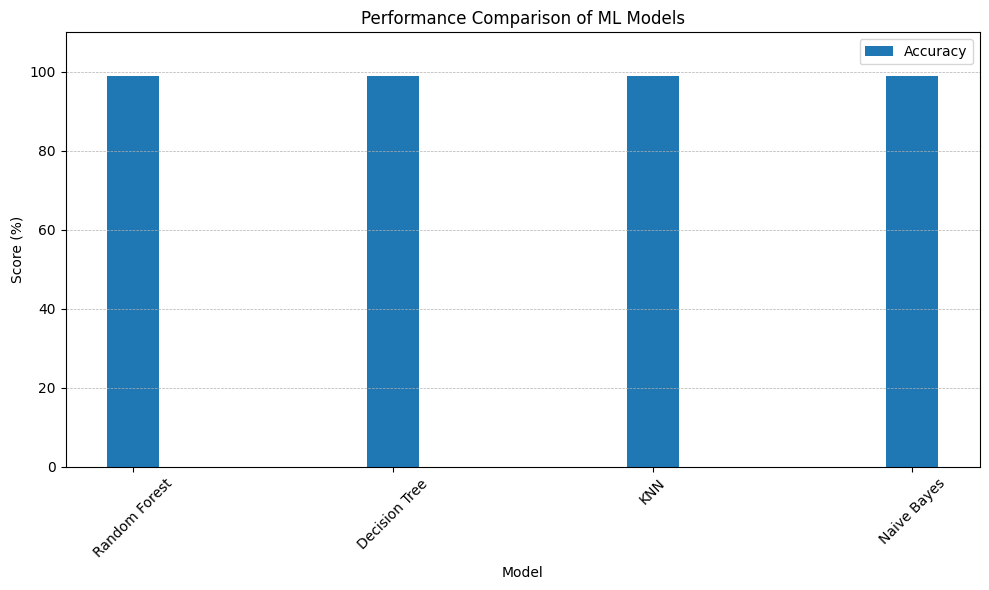

In [13]:
import matplotlib.pyplot as plt

# Prepare performance metrics for graph
model_names = list(model_performance.keys())
accuracies = [model_performance[m]["Accuracy"] for m in model_names]


# Plot
plt.figure(figsize=(10, 6))
bar_width = 0.2
r1 = range(len(model_names))


plt.bar(r1, accuracies, width=bar_width, label='Accuracy')


plt.xlabel('Model')
plt.ylabel('Score (%)')
plt.title('Performance Comparison of ML Models')
plt.xticks([r for r in range(len(model_names))], model_names, rotation=45)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.show()
